# Análisis de Datos e Inferencia Estadística
## Introducción al Análisis de Datos en Salud y GRD

**Objetivos de la sesión:**
1. Comprender el contexto y la importancia de los datos en sistemas de salud
2. Familiarizarse con la estructura y componentes de los Grupos Relacionados por Diagnóstico (GRD)
3. Aplicar técnicas básicas de exploración y visualización de datos
4. Formular preguntas preliminares de investigación basadas en los datos disponibles

En este curso utilizaremos un conjunto de datos real del sistema sanitario chileno, específicamente datos de GRD de 68 hospitales correspondientes al año 2023.

## 1. Contexto: ¿Qué son los GRD y por qué son importantes?

Los **Grupos Relacionados por Diagnóstico (GRD)** constituyen un sistema de clasificación que permite relacionar los distintos tipos de patologías y procedimientos médicos con el costo que implica cada tratamiento.

Estos grupos tienen tres usos principales en los sistemas de salud:

1. **Evaluación de gestión clínica**: Permiten comparar el desempeño entre hospitales y servicios de salud.
2. **Mecanismo de pago**: Facilitan un sistema de reembolso más equitativo y eficiente.
3. **Mejora de la calidad asistencial**: Ayudan a identificar áreas de mejora en la atención médica.

Chile ha sido pionero en América Latina en la implementación de GRD. Desde 2015, FONASA (Fondo Nacional de Salud) ha utilizado este sistema para financiar hospitales, expandiéndose gradualmente hasta alcanzar los 68 establecimientos en 2023.

Los GRD toman en cuenta factores como:
- Diagnóstico principal
- Comorbilidades
- Complicaciones
- Procedimientos realizados
- Edad y sexo del paciente

Esta información permite asignar a cada paciente un código GRD con un "peso" asociado, que refleja la complejidad y el costo relativo del caso.

## 2. Carga y exploración inicial de los datos

Comencemos cargando las bibliotecas necesarias y el conjunto de datos principal.

In [1]:
# Importamos las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

# Para mostrar todas las columnas en la salida
pd.set_option('display.max_columns', None)

In [4]:
# Cargamos el dataset principal (ajustar la ruta según sea necesario)
# Este archivo contiene los datos de egresos hospitalarios con información de GRD
df_grd = pd.read_csv("datos/GRD_2023_muestra.csv",
        sep="|",  # Delimitador de columnas
        encoding="UTF-8",  # Cambiar si necesario (latin1, ISO-8859-1, etc.)
        low_memory=False,  # Evitar advertencias de memoria
        parse_dates=['FECHA_NACIMIENTO', 'FECHA_INGRESO', 'FECHAALTA'],  # Leer columnas como fechas
        dayfirst=False  # Formato de fecha año-mes-día 
        )

# Mostramos las primeras filas para entender la estructura
df_grd.head()

,COD_HOSPITAL,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,SERVICIO_SALUD,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,TIPO_FECHA_NACIMIENTO,TIPO_FECHA_INGRESO,TIPO_FECHAALTA,EDAD_INGRESO,ESTANCIA,ESTANCIA_INT
0,122100,72196813,HOMBRE,1980-04-13,VALDIVIA,2023-03-12,2023-03-14,DOMICILIO,K35.3,064161,0.7094,1,1,YMD,DMY,DMY,42,2,2
1,114101,DESCONOCIDO,HOMBRE,2001-11-04,METROPOLITANO SURORIENTE,2023-11-04,2023-11-10,DOMICILIO,J93.1,041301,1.0869,1,1,YMD,DMY,DMY,22,6,6
2,114101,97627974,HOMBRE,2020-07-30,METROPOLITANO SURORIENTE,2023-06-07,2023-06-08,HOSPITALIZACIÓN DOMICILIARIA,J12.1,044161,0.4084,1,1,YMD,DMY,DMY,2,1,1
3,106103,67770674,MUJER,1978-11-14,VALPARAISO SAN ANTONIO,2023-05-25,2023-05-26,DOMICILIO,N39.3,131301,0.6406,1,1,YMD,DMY,DMY,44,1,1
4,106103,100390800,MUJER,2023-12-20,VALPARAISO SAN ANTONIO,2023-12-28,2023-12-30,DOMICILIO,R17,074131,0.5346,1,1,YMD,DMY,DMY,0,2,2


### Carga de tablas maestras

Para interpretar correctamente los códigos en nuestro dataset principal, necesitamos cargar varias tablas maestras que contienen información de referencia.

In [6]:
# Cargamos tabla maestra de hospitales
df_hospitales = pd.read_csv("datos/Hospitales.csv", header=None, names=['COD_HOSPITAL', 'NOMBRE_HOSPITAL'], sep="|")

# Cargamos tabla de códigos GRD y sus descripciones
df_grd_codigos = pd.read_csv("datos/IR-GRD.csv", header=None, names=['COD_GRD', 'DESCRIPCION_GRD'], sep="|")

# Cargamos tabla de niveles de severidad
df_severidad = pd.read_csv("datos/Severidad.csv", header=None, names=['CODIGO', 'SEVERIDAD'], sep="|")

# Cargamos tabla de niveles de mortalidad
df_mortalidad = pd.read_csv("datos/Mortalidad.csv", header=None, names=['CODIGO', 'MORTALIDAD'], sep="|")

# Mostramos las primeras filas de cada tabla maestra
print("Tabla de Hospitales:")
display(df_hospitales.head())
print("\nTabla de Códigos GRD:")
display(df_grd_codigos.head())
print("\nTabla de Severidad:")
display(df_severidad)
print("\nTabla de Mortalidad:")
display(df_mortalidad)

Tabla de Hospitales:


,COD_HOSPITAL,NOMBRE_HOSPITAL
0,101100,Hospital Dr. Juan Noé Crevanni (Arica)
1,101203,Clínica Hebe
2,101212,Clínica San Agustín
3,101213,Clínica San José
4,101215,Complejo Penitenciario



Tabla de Códigos GRD:


,COD_GRD,DESCRIPCION_GRD
0,11011,PH PROCEDIMIENTOS VASCULARES INTRACRANEALES
1,11012,PH PROCEDIMIENTOS VASCULARES INTRACRANEALES W/CC
2,11013,PH PROCEDIMIENTOS VASCULARES INTRACRANEALES W...
3,11101,PH CRANEOTOMÍA
4,11102,PH CRANEOTOMÍA W/CC



Tabla de Severidad:


,CODIGO,SEVERIDAD
0,0,Sin gravedad
1,1,Menor
2,2,Moderada
3,3,Mayor



Tabla de Mortalidad:


,CODIGO,MORTALIDAD
0,0,Sin gravedad
1,1,Menor
2,2,Moderada
3,3,Mayor


## 3. Exploración y limpieza básica de los datos

Antes de comenzar cualquier análisis, es fundamental entender la estructura de nuestros datos y realizar una limpieza básica.

In [7]:
# Verificamos la información general del dataset
df_grd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1039577 entries, 0 to 1039576
Data columns (total 19 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   COD_HOSPITAL           1039577 non-null  int64         
 1   CIP_ENCRIPTADO         1039577 non-null  object        
 2   SEXO                   1039577 non-null  object        
 3   FECHA_NACIMIENTO       1039577 non-null  datetime64[ns]
 4   SERVICIO_SALUD         1039577 non-null  object        
 5   FECHA_INGRESO          1039577 non-null  datetime64[ns]
 6   FECHAALTA              1039577 non-null  datetime64[ns]
 7   TIPOALTA               1039577 non-null  object        
 8   DIAGNOSTICO1           1039577 non-null  object        
 9   IR_29301_COD_GRD       1039577 non-null  object        
 10  IR_29301_PESO          1039547 non-null  float64       
 11  IR_29301_SEVERIDAD     1039577 non-null  object        
 12  IR_29301_MORTALIDAD    10395

In [ ]:
# Verificamos si hay valores nulos o faltantes
print("Valores nulos por columna:")
print(df_grd.isnull().sum())

# Verificamos valores únicos en algunas columnas clave
print("\nValores únicos en columna SEXO:")
print(df_grd['SEXO'].unique())

print("\nValores únicos en columna TIPOALTA:")
print(df_grd['TIPOALTA'].unique())

Valores nulos por columna:
COD_HOSPITAL              0
CIP_ENCRIPTADO            0
SEXO                      0
FECHA_NACIMIENTO          0
SERVICIO_SALUD            0
FECHA_INGRESO             0
FECHAALTA                 0
TIPOALTA                  0
DIAGNOSTICO1              0
IR_29301_COD_GRD          0
IR_29301_PESO            30
IR_29301_SEVERIDAD        0
IR_29301_MORTALIDAD       0
TIPO_FECHA_NACIMIENTO     0
TIPO_FECHA_INGRESO        0
TIPO_FECHAALTA            0
EDAD_INGRESO              0
ESTANCIA                  0
ESTANCIA_INT              0
dtype: int64

Valores únicos en columna SEXO:
['HOMBRE' 'MUJER' 'DESCONOCIDO']

Valores únicos en columna TIPOALTA:
['DOMICILIO' 'HOSPITALIZACIÓN DOMICILIARIA'
 'DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS'
 'DERIVACIÓN OTRO HOSPITAL DEL SERVICIO' 'FUGA DEL PACIENTE'
 'DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL' 'ALTA VOLUNTARIA'
 'FALLECIDO' 'DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE'
 'DERIVACIÓN INST. PRIVADA (VOLUNTARIO)']


In [8]:
# Función para convertir fechas

def convert_date(date_str):
    try:
        pd.to_datetime(date_str, format='%d-%m-%Y')  # Primero intentamos día-mes-año
        return pd.to_datetime(date_str, format='%d-%m-%Y'), 'DMY'
    except ValueError:
        try:
            pd.to_datetime(date_str, format='%Y-%m-%d')  # Luego año-mes-día
            return pd.to_datetime(date_str, format='%Y-%m-%d'), 'YMD'
        except ValueError:
            return pd.NaT, 'Invalid'  # Si falla, dejamos NaT (valor nulo)

In [9]:
df_grd[['FECHA_NACIMIENTO', 'TIPO_FECHA_NACIMIENTO']] = df_grd['FECHA_NACIMIENTO'].apply(lambda x: pd.Series(convert_date(x)))


In [10]:
df_grd[['FECHA_INGRESO', 'TIPO_FECHA_INGRESO']] = df_grd['FECHA_INGRESO'].apply(lambda x: pd.Series(convert_date(x)))


In [11]:
df_grd[['FECHAALTA', 'TIPO_FECHAALTA']] = df_grd['FECHAALTA'].apply(lambda x: pd.Series(convert_date(x)))


In [12]:
# Convertimos las fechas a formato datetime para facilitar análisis temporales
df_grd['FECHA_NACIMIENTO'] = pd.to_datetime(df_grd['FECHA_NACIMIENTO'], dayfirst=True)
df_grd['FECHA_INGRESO'] = pd.to_datetime(df_grd['FECHA_INGRESO'], dayfirst=True)
df_grd['FECHAALTA'] = pd.to_datetime(df_grd['FECHAALTA'], dayfirst=True)

# Calculamos la edad del paciente y la duración de la estancia
df_grd['EDAD'] = ((df_grd['FECHA_INGRESO'] - df_grd['FECHA_NACIMIENTO']).dt.days / 365.25).round().astype('Int64')
df_grd['DIAS_ESTANCIA'] = (df_grd['FECHAALTA'] - df_grd['FECHA_INGRESO']).dt.days

# Convertimos los códigos de severidad y mortalidad a tipo numérico
df_grd['IR_29301_SEVERIDAD'] = pd.to_numeric(df_grd['IR_29301_SEVERIDAD'], errors='coerce')
df_grd['IR_29301_MORTALIDAD'] = pd.to_numeric(df_grd['IR_29301_MORTALIDAD'], errors='coerce')

# Convertimos el peso GRD a tipo float
#df_grd['IR_29301_PESO'] = df_grd['IR_29301_PESO'].str.replace(',', '.').str.strip()
df_grd['IR_29301_PESO'] = pd.to_numeric(df_grd['IR_29301_PESO'], errors='coerce')

# Verificamos las nuevas columnas
df_grd[['FECHA_NACIMIENTO', 'FECHA_INGRESO', 'FECHAALTA', 'EDAD', 'DIAS_ESTANCIA']].head()

,FECHA_NACIMIENTO,FECHA_INGRESO,FECHAALTA,EDAD,DIAS_ESTANCIA
0,1980-04-13,2023-03-12,2023-03-14,43,2
1,2001-11-04,2023-11-04,2023-11-10,22,6
2,2020-07-30,2023-06-07,2023-06-08,3,1
3,1978-11-14,2023-05-25,2023-05-26,45,1
4,2023-12-20,2023-12-28,2023-12-30,0,2


## 4. Análisis exploratorio básico

Ahora realizaremos un análisis exploratorio básico para comenzar a entender los patrones en nuestros datos.

In [13]:
# Estadísticas descriptivas básicas
print("Estadísticas descriptivas de variables numéricas:")
df_grd[['EDAD', 'DIAS_ESTANCIA', 'IR_29301_PESO', 'IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD']].describe().T

Estadísticas descriptivas de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
EDAD,1039577.0,44.895745,25.713463,0.0,25.0,45.0,67.0,109.0
DIAS_ESTANCIA,1039577.0,5.79622,12.348344,0.0,1.0,2.0,6.0,696.0
IR_29301_PESO,1039547.0,0.960285,1.090845,0.0,0.4726,0.6915,1.0328,20.6461
IR_29301_SEVERIDAD,1039547.0,1.450184,1.006378,0.0,1.0,1.0,2.0,3.0
IR_29301_MORTALIDAD,1039547.0,1.300224,0.953503,0.0,1.0,1.0,2.0,3.0


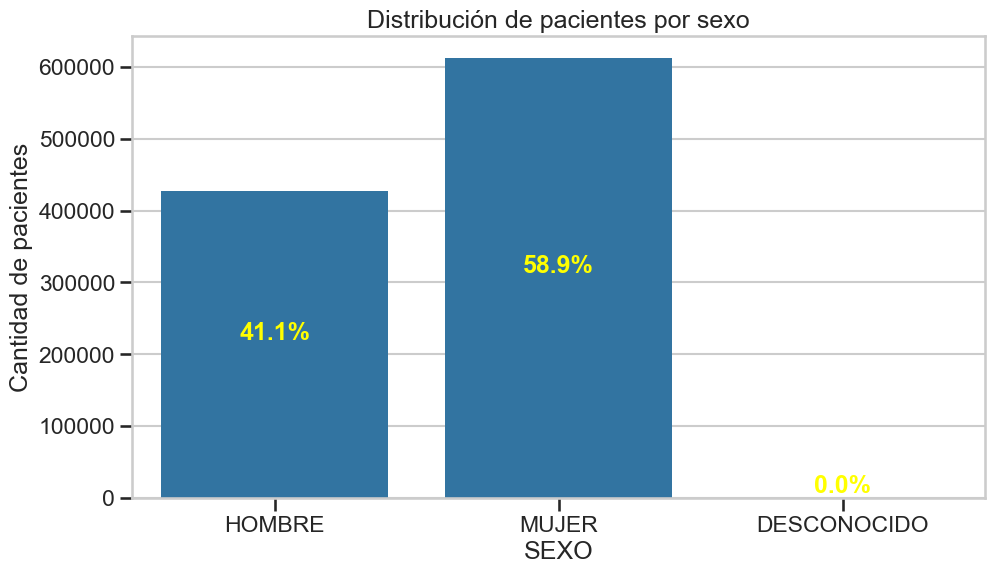

In [14]:
# Distribución por sexo
plt.figure(figsize=(11, 6))
ax = sns.countplot(data=df_grd, x='SEXO')
plt.title('Distribución de pacientes por sexo')
plt.ylabel('Cantidad de pacientes')
plt.xticks(rotation=0)

# Añadir porcentaje en las barras
total = len(df_grd)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() /2
    ax.annotate(percentage, (x, y), ha='center', va='bottom', color='yellow', weight='bold')

plt.show()

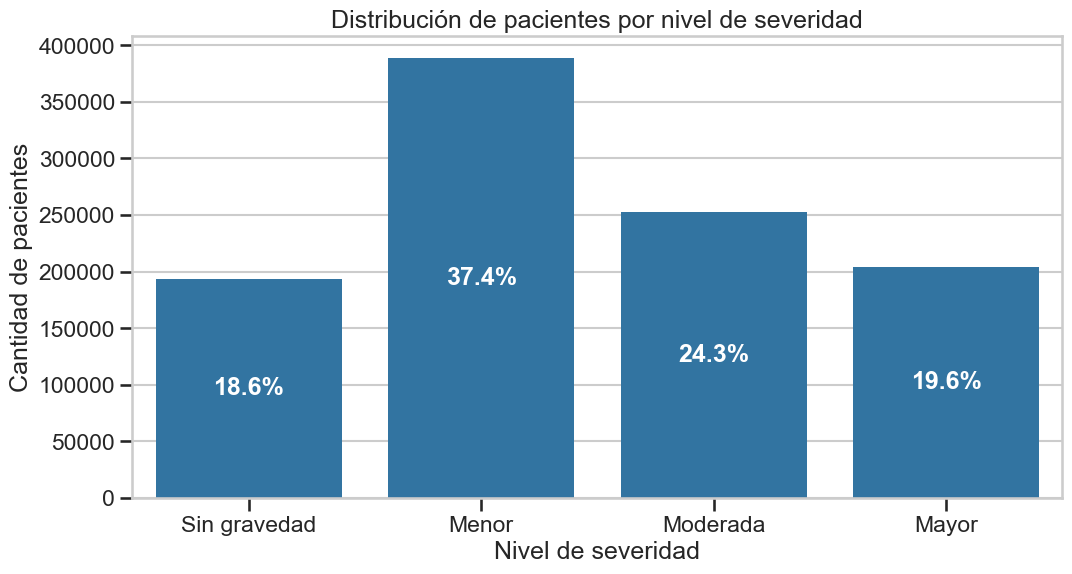

In [15]:
# Distribución por nivel de severidad
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_grd, x='IR_29301_SEVERIDAD')
plt.title('Distribución de pacientes por nivel de severidad')
plt.xlabel('Nivel de severidad')
plt.ylabel('Cantidad de pacientes')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Sin gravedad', 'Menor', 'Moderada', 'Mayor'])

# Añadir porcentaje en las barras
total = len(df_grd)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() / 2
    ax.annotate(percentage, (x, y), ha='center', va='center', color='white', weight='bold')

plt.show()

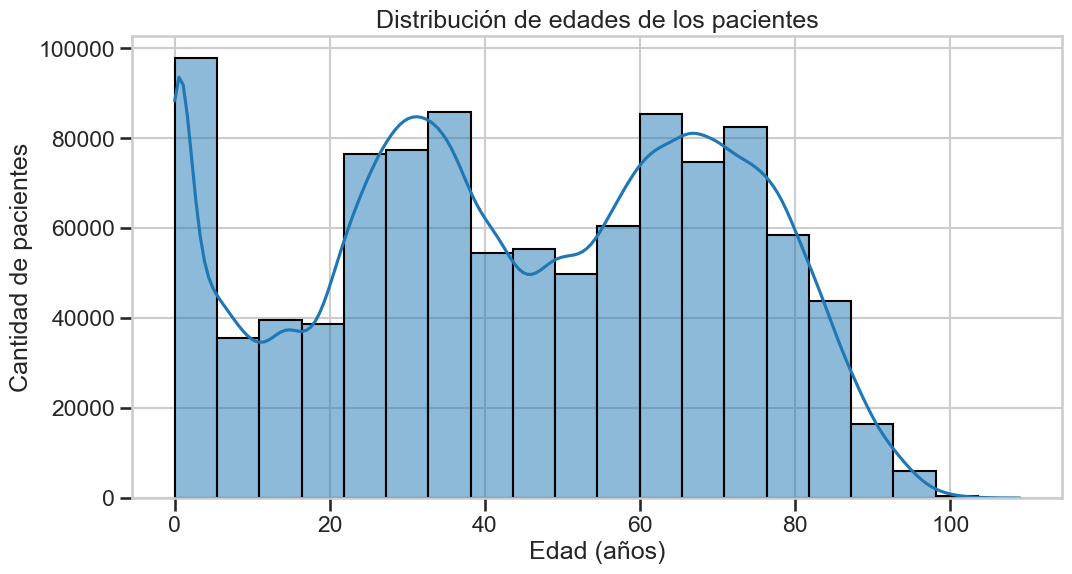

In [16]:
# Histograma de la distribución de edades
plt.figure(figsize=(12, 6))
sns.histplot(data=df_grd, x='EDAD', bins=20, kde=True)
plt.title('Distribución de edades de los pacientes')
plt.xlabel('Edad (años)')
plt.ylabel('Cantidad de pacientes')
plt.show()

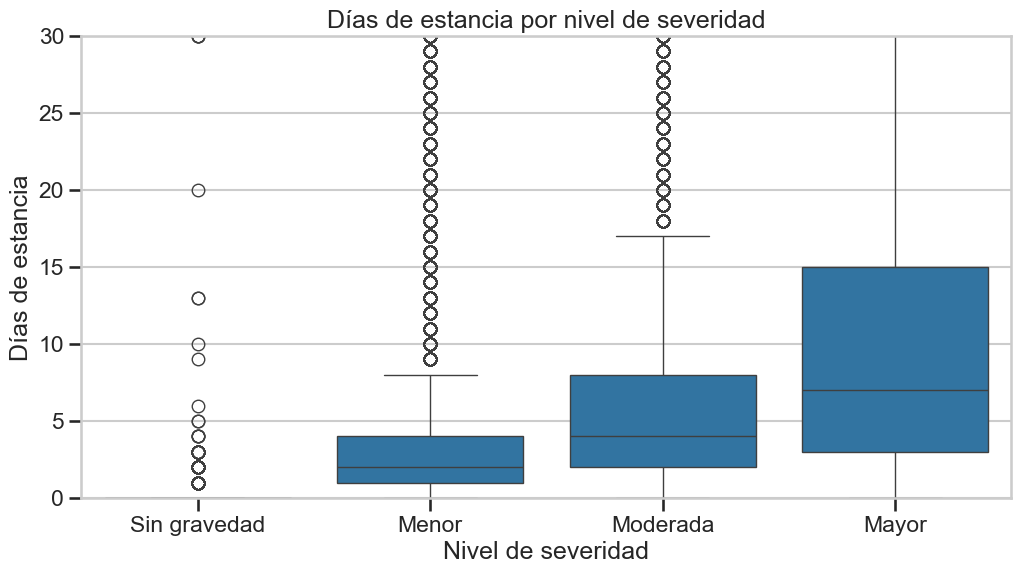

In [17]:
# Relación entre severidad y días de estancia
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_grd, x='IR_29301_SEVERIDAD', y='DIAS_ESTANCIA')
plt.title('Días de estancia por nivel de severidad')
plt.xlabel('Nivel de severidad')
plt.ylabel('Días de estancia')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Sin gravedad', 'Menor', 'Moderada', 'Mayor'])
plt.ylim(0, 30)  # Limitamos el eje Y para mejor visualización
plt.show()

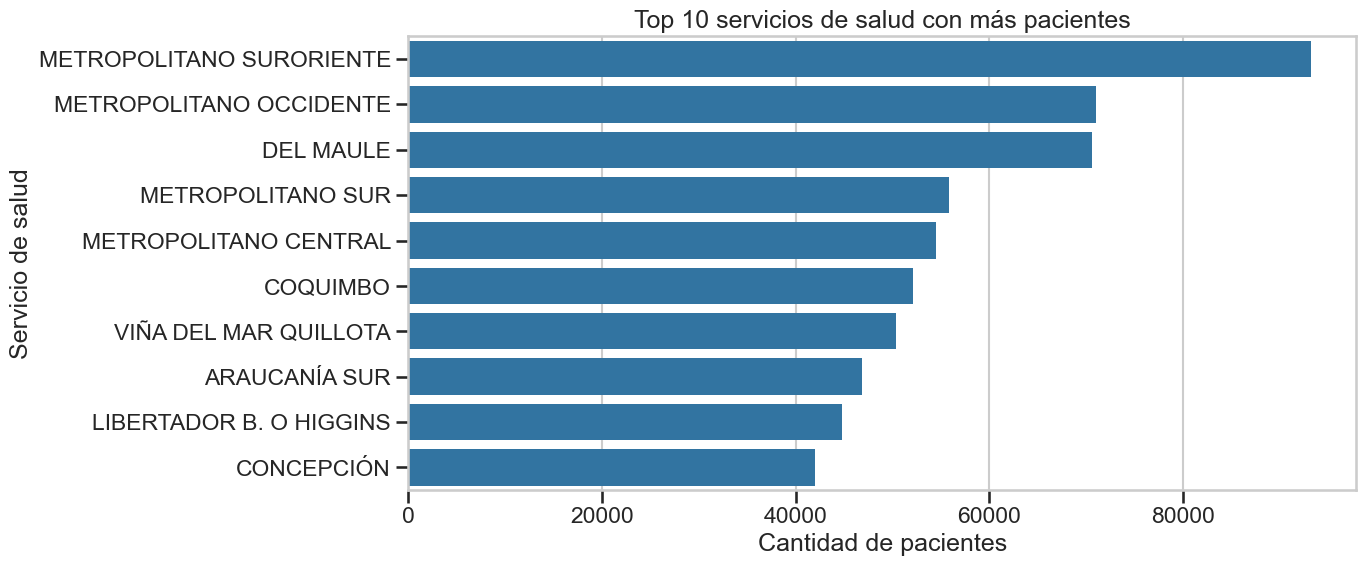

In [18]:
# Top 10 servicios de salud con más pacientes
plt.figure(figsize=(14, 6))
top_10_servicios = df_grd['SERVICIO_SALUD'].value_counts().head(10)
sns.barplot(y=top_10_servicios.index, x=top_10_servicios.values, orient='h')
plt.title('Top 10 servicios de salud con más pacientes')
plt.ylabel('Servicio de salud')
plt.xlabel('Cantidad de pacientes')
plt.tight_layout()
plt.show()


## 5. Enriquecimiento de datos con tablas maestras

Para facilitar la interpretación de los datos, podemos enriquecer nuestro dataset principal con información de las tablas maestras.

In [19]:
df_grd.head()

,COD_HOSPITAL,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,SERVICIO_SALUD,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,TIPO_FECHA_NACIMIENTO,TIPO_FECHA_INGRESO,TIPO_FECHAALTA,EDAD_INGRESO,ESTANCIA,ESTANCIA_INT,EDAD,DIAS_ESTANCIA
0,122100,72196813,HOMBRE,1980-04-13,VALDIVIA,2023-03-12,2023-03-14,DOMICILIO,K35.3,064161,0.7094,1.0,1.0,DMY,DMY,DMY,42,2,2,43,2
1,114101,DESCONOCIDO,HOMBRE,2001-11-04,METROPOLITANO SURORIENTE,2023-11-04,2023-11-10,DOMICILIO,J93.1,041301,1.0869,1.0,1.0,DMY,DMY,DMY,22,6,6,22,6
2,114101,97627974,HOMBRE,2020-07-30,METROPOLITANO SURORIENTE,2023-06-07,2023-06-08,HOSPITALIZACIÓN DOMICILIARIA,J12.1,044161,0.4084,1.0,1.0,DMY,DMY,DMY,2,1,1,3,1
3,106103,67770674,MUJER,1978-11-14,VALPARAISO SAN ANTONIO,2023-05-25,2023-05-26,DOMICILIO,N39.3,131301,0.6406,1.0,1.0,DMY,DMY,DMY,44,1,1,45,1
4,106103,100390800,MUJER,2023-12-20,VALPARAISO SAN ANTONIO,2023-12-28,2023-12-30,DOMICILIO,R17,074131,0.5346,1.0,1.0,DMY,DMY,DMY,0,2,2,0,2


In [20]:
df_grd_codigos['COD_GRD'] = df_grd_codigos['COD_GRD'].astype(str)
df_grd_codigos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1066 entries, 0 to 1065
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   COD_GRD          1066 non-null   object
 1   DESCRIPCION_GRD  1066 non-null   object
dtypes: object(2)
memory usage: 16.8+ KB


In [21]:
# Convert the column to numeric, setting errors='coerce' to handle non-numeric values
df_grd['IR_29301_COD_GRD'] = pd.to_numeric(df_grd['IR_29301_COD_GRD'], errors='coerce')

# Optionally, fill NaN values with a specific value, e.g., 0
df_grd['IR_29301_COD_GRD'] = df_grd['IR_29301_COD_GRD'].fillna(0)

# Convert the column to integer type
df_grd['IR_29301_COD_GRD'] = df_grd['IR_29301_COD_GRD'].astype(int)


In [22]:
df_grd['IR_29301_COD_GRD'] = df_grd['IR_29301_COD_GRD'].astype(str)
df_grd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1039577 entries, 0 to 1039576
Data columns (total 21 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   COD_HOSPITAL           1039577 non-null  int64         
 1   CIP_ENCRIPTADO         1039577 non-null  object        
 2   SEXO                   1039577 non-null  object        
 3   FECHA_NACIMIENTO       1039577 non-null  datetime64[ns]
 4   SERVICIO_SALUD         1039577 non-null  object        
 5   FECHA_INGRESO          1039577 non-null  datetime64[ns]
 6   FECHAALTA              1039577 non-null  datetime64[ns]
 7   TIPOALTA               1039577 non-null  object        
 8   DIAGNOSTICO1           1039577 non-null  object        
 9   IR_29301_COD_GRD       1039577 non-null  object        
 10  IR_29301_PESO          1039547 non-null  float64       
 11  IR_29301_SEVERIDAD     1039547 non-null  float64       
 12  IR_29301_MORTALIDAD    10395

In [23]:
df_grd[df_grd.IR_29301_COD_GRD == '64161'].head()

,COD_HOSPITAL,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,SERVICIO_SALUD,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,TIPO_FECHA_NACIMIENTO,TIPO_FECHA_INGRESO,TIPO_FECHAALTA,EDAD_INGRESO,ESTANCIA,ESTANCIA_INT,EDAD,DIAS_ESTANCIA
0,122100,72196813,HOMBRE,1980-04-13,VALDIVIA,2023-03-12,2023-03-14,DOMICILIO,K35.3,64161,0.7094,1.0,1.0,DMY,DMY,DMY,42,2,2,43,2
4813,115100,74516576,HOMBRE,2009-03-06,LIBERTADOR B. O HIGGINS,2023-08-25,2023-08-30,DOMICILIO,K35.3,64161,0.7094,1.0,1.0,DMY,DMY,DMY,14,5,5,14,5
13037,121109,76376070,HOMBRE,1970-01-14,ARAUCANÍA SUR,2023-02-08,2023-02-10,DOMICILIO,K35.2,64161,0.7094,1.0,1.0,DMY,DMY,DMY,53,2,2,53,2
13047,106102,99182039,MUJER,1995-11-09,VALPARAISO SAN ANTONIO,2023-04-15,2023-04-19,DOMICILIO,K65.8,64161,0.7094,1.0,1.0,DMY,DMY,DMY,27,4,4,27,4
21384,108101,71000139,HOMBRE,1955-09-29,ACONCAGUA,2023-03-11,2023-03-21,DOMICILIO,K35.2,64161,0.7094,1.0,1.0,DMY,DMY,DMY,67,10,10,67,10


In [24]:
df_grd_codigos[df_grd_codigos.COD_GRD == '64161'].head()

,COD_GRD,DESCRIPCION_GRD
419,64161,MH INFECCIONES GASTROINTESTINALES MAYORES


In [25]:
# Añadimos nombres de hospitales
df_enriquecido = df_grd.merge(df_hospitales, on='COD_HOSPITAL', how='left')

# Añadimos descripciones de GRD
# Primero, extraemos solo el código numérico del GRD (sin el prefijo)
df_enriquecido['GRD_CODIGO_LIMPIO'] = df_enriquecido['IR_29301_COD_GRD'].str.extract(r'(\d+)')
df_grd_codigos['GRD_CODIGO_LIMPIO'] = df_grd_codigos['COD_GRD'].str.extract(r'(\d+)')
df_enriquecido = df_enriquecido.merge(df_grd_codigos[['GRD_CODIGO_LIMPIO', 'DESCRIPCION_GRD']], on='GRD_CODIGO_LIMPIO', how='left')

# Añadimos descripciones de severidad y mortalidad
df_enriquecido = df_enriquecido.merge(df_severidad, left_on='IR_29301_SEVERIDAD', right_on='CODIGO', how='left')
df_enriquecido = df_enriquecido.merge(df_mortalidad, left_on='IR_29301_MORTALIDAD', right_on='CODIGO', how='left', suffixes=('_sev', '_mor'))

# Verificamos el resultado
df_enriquecido[['COD_HOSPITAL', 'NOMBRE_HOSPITAL', 'IR_29301_COD_GRD', 'DESCRIPCION_GRD',
               'IR_29301_SEVERIDAD', 'SEVERIDAD', 'IR_29301_MORTALIDAD', 'MORTALIDAD']].head()

,COD_HOSPITAL,NOMBRE_HOSPITAL,IR_29301_COD_GRD,DESCRIPCION_GRD,IR_29301_SEVERIDAD,SEVERIDAD,IR_29301_MORTALIDAD,MORTALIDAD
0,122100,Hospital Clínico Regional (Valdivia),64161,MH INFECCIONES GASTROINTESTINALES MAYORES,1.0,Menor,1.0,Menor
1,114101,Complejo Hospitalario Dr. Sótero del Río (San...,41301,PH PROCEDIMIENTOS MODERADAMENTE COMPLEJOS SOB...,1.0,Menor,1.0,Menor
2,114101,Complejo Hospitalario Dr. Sótero del Río (San...,44161,MH NEUMONÍA SIMPLE Y TOS FERINA,1.0,Menor,1.0,Menor
3,106103,Hospital Claudio Vicuña (San Antonio),131301,PH HISTERECTOMIA VAGINAL Y OTROS PROCEDIMIENT...,1.0,Menor,1.0,Menor
4,106103,Hospital Claudio Vicuña (San Antonio),74131,"MH ENFERMEDADES HEPÁTICAS EXCEPTO NEOPLASIAS,...",1.0,Menor,1.0,Menor


## 6. Análisis exploratorio con datos enriquecidos

Ahora podemos realizar análisis más significativos usando las descripciones.

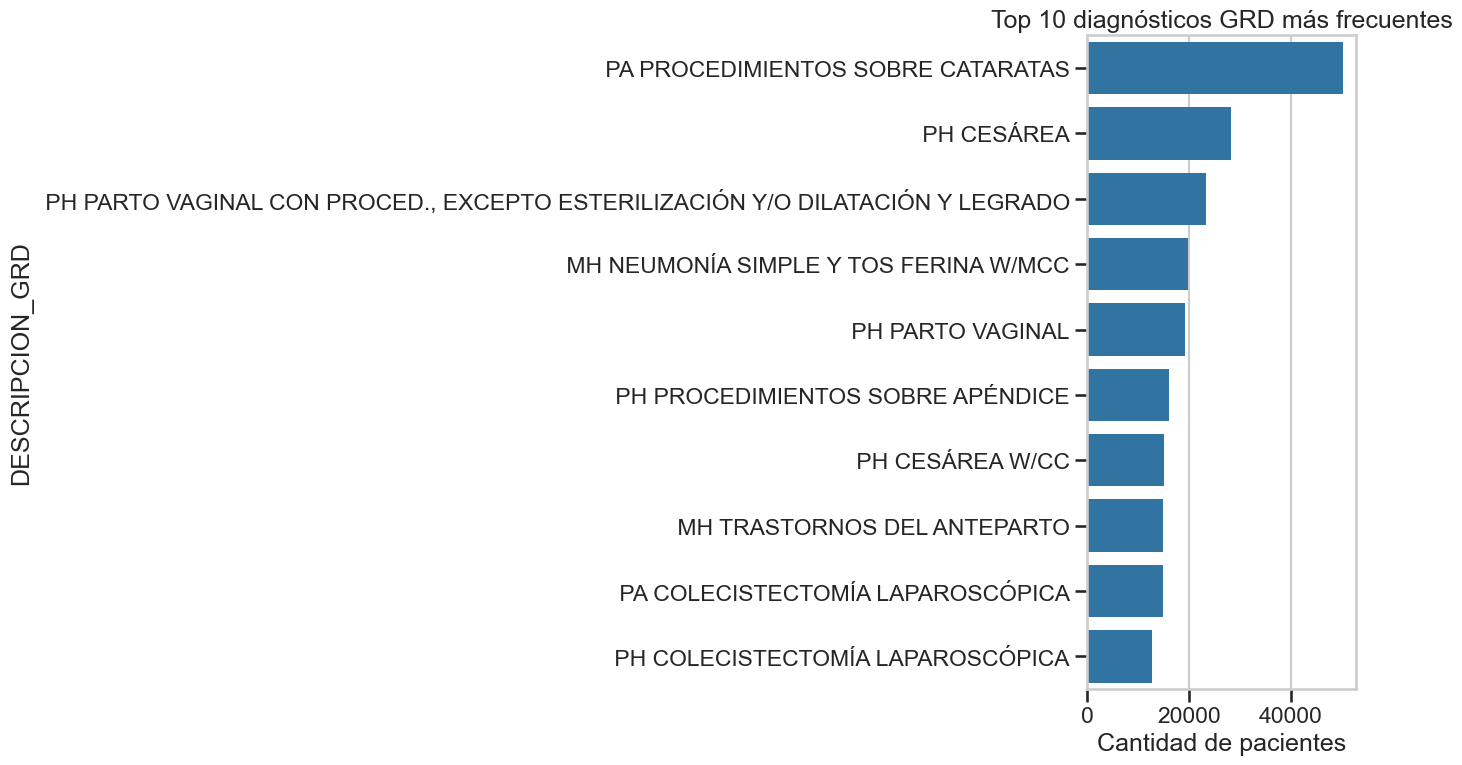

In [26]:
# Top 10 diagnósticos más frecuentes
plt.figure(figsize=(14, 8))
top_10_grd = df_enriquecido['DESCRIPCION_GRD'].value_counts().head(10)
sns.barplot(x=top_10_grd.values, y=top_10_grd.index)
plt.title('Top 10 diagnósticos GRD más frecuentes')
plt.xlabel('Cantidad de pacientes')
plt.tight_layout()
plt.show()

<Figure size 3000x1000 with 0 Axes>

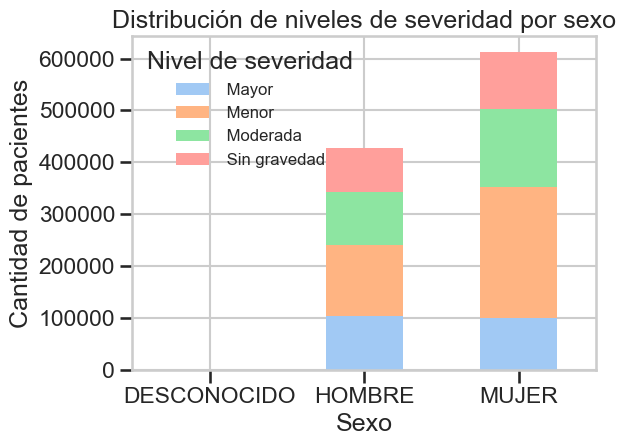

In [27]:
# Distribución de niveles de severidad por sexo
plt.figure(figsize=(30, 10))
crosstab = pd.crosstab(df_enriquecido['SEXO'], df_enriquecido['SEVERIDAD'])
crosstab.plot(kind='bar', stacked=True, color=sns.color_palette("pastel"))
plt.title('Distribución de niveles de severidad por sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de pacientes')
plt.legend(title='Nivel de severidad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


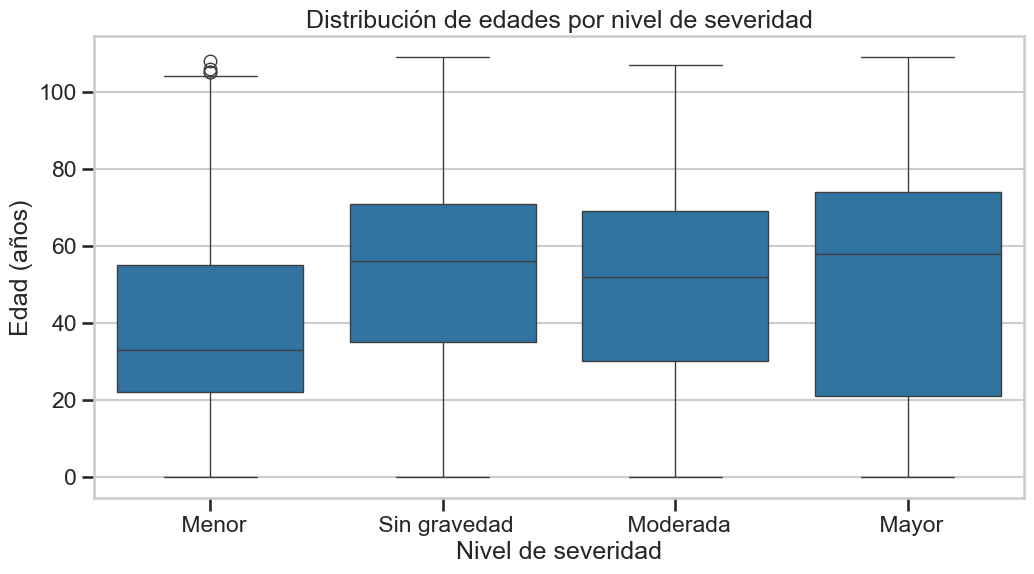

In [28]:
# Relación entre edad y severidad
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_enriquecido, x='SEVERIDAD', y='EDAD')
plt.title('Distribución de edades por nivel de severidad')
plt.xlabel('Nivel de severidad')
plt.ylabel('Edad (años)')
plt.show()

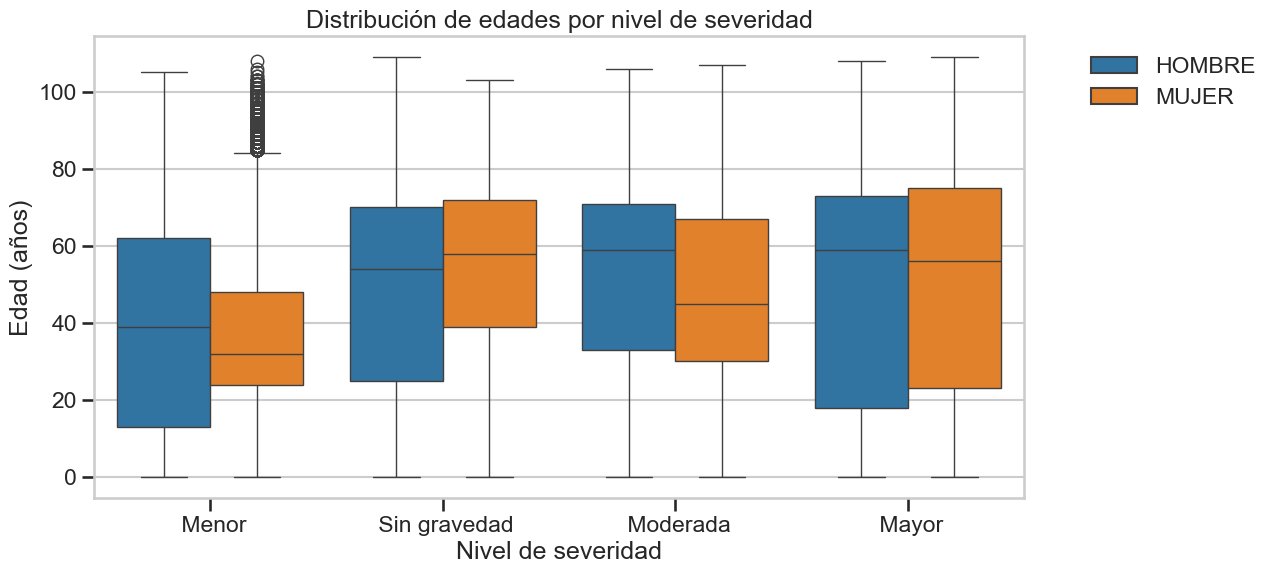

In [29]:
# Relación entre edad y severidad
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_enriquecido[df_enriquecido.SEXO!='DESCONOCIDO'], x='SEVERIDAD', y='EDAD', hue='SEXO')
plt.title('Distribución de edades por nivel de severidad')
plt.xlabel('Nivel de severidad')
plt.ylabel('Edad (años)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Mueve la leyenda fuera del área del gráfico
plt.show()

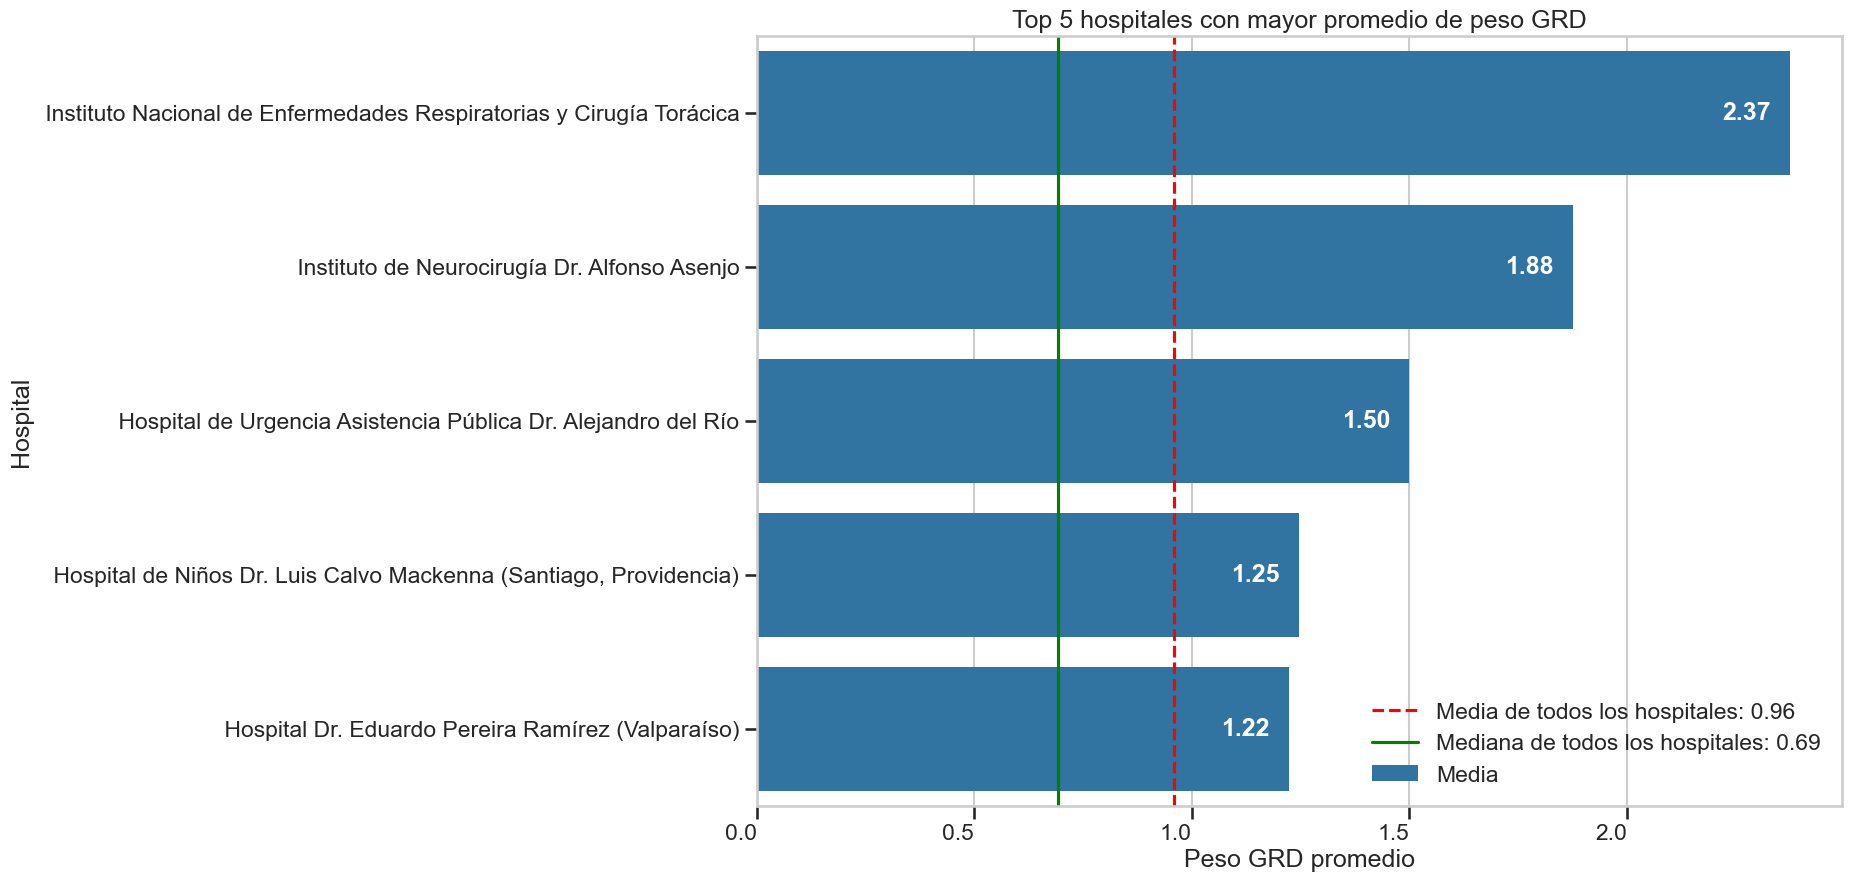

In [30]:
# Top 5 hospitales con mayor promedio de peso GRD (mayor complejidad)
hospital_peso = df_enriquecido.groupby('NOMBRE_HOSPITAL')['IR_29301_PESO'].agg(['mean', 'median', 'count'])
hospital_peso = hospital_peso[hospital_peso['count'] > 100]  # Filtramos hospitales con pocos casos
hospital_peso = hospital_peso.sort_values('mean', ascending=False).head(5)

# Calculamos la media y mediana de todos los hospitales
mean_all = df_enriquecido['IR_29301_PESO'].mean()
median_all = df_enriquecido['IR_29301_PESO'].median()

plt.figure(figsize=(14, 10))
ax = sns.barplot(y=hospital_peso.index, x=hospital_peso['mean'], orient='h', label='Media')
plt.title('Top 5 hospitales con mayor promedio de peso GRD')
plt.ylabel('Hospital')
plt.xlabel('Peso GRD promedio')
plt.xticks(rotation=0, ha='right')

# Añadimos líneas verticales para la media y mediana de todos los hospitales
plt.axvline(mean_all, color='r', linestyle='--', label=f'Media de todos los hospitales: {mean_all:.2f}')
plt.axvline(median_all, color='g', linestyle='-', label=f'Mediana de todos los hospitales: {median_all:.2f}')

# Añadimos el promedio dentro de la barra en color blanco
for p in ax.patches:
    width = p.get_width()
    plt.text(width - 0.1, p.get_y() + p.get_height() / 2, f'{width:.2f}', ha='center', va='center', color='white', weight='bold')

plt.legend()
plt.show()


## 7. Actividad práctica en grupos

A continuación, realizarán una actividad en grupos para explorar más a fondo los datos y comenzar a formular preguntas de investigación.

### Instrucciones:

1. Formen grupos de 2-3 estudiantes.
2. Cada grupo debe seleccionar un servicio de salud específico para analizar.
3. Para su servicio de salud asignado, deben completar las siguientes tareas:

### Tareas:

a) Filtrar los datos para obtener solo los registros del servicio de salud seleccionado.

b) Realizar un análisis exploratorio básico que incluya:
   - Distribución de pacientes por sexo y edad
   - Top 5 diagnósticos más frecuentes
   - Distribución de niveles de severidad
   - Relación entre severidad y días de estancia

c) Formular al menos tres preguntas de investigación interesantes basadas en su exploración inicial.

d) Identificar al menos dos desafíos o limitaciones en los datos que podrían afectar su análisis.

e) Proponer un enfoque preliminar para responder a una de sus preguntas de investigación.

### Plantilla para comenzar:

In [50]:
# ACTIVIDAD GRUPAL  
# Reemplazar con el nombre del servicio de salud seleccionado
servicio_seleccionado = "DEL MAULE"

# Filtrar datos para el servicio seleccionado
df_servicio = df_enriquecido[df_enriquecido['SERVICIO_SALUD'] == servicio_seleccionado].copy()

# Verificar el número de registros
print(f"Número de registros para {servicio_seleccionado}: {len(df_servicio)}")

Número de registros para DEL MAULE: 70645


## b) Ánalisis Exploratorio 

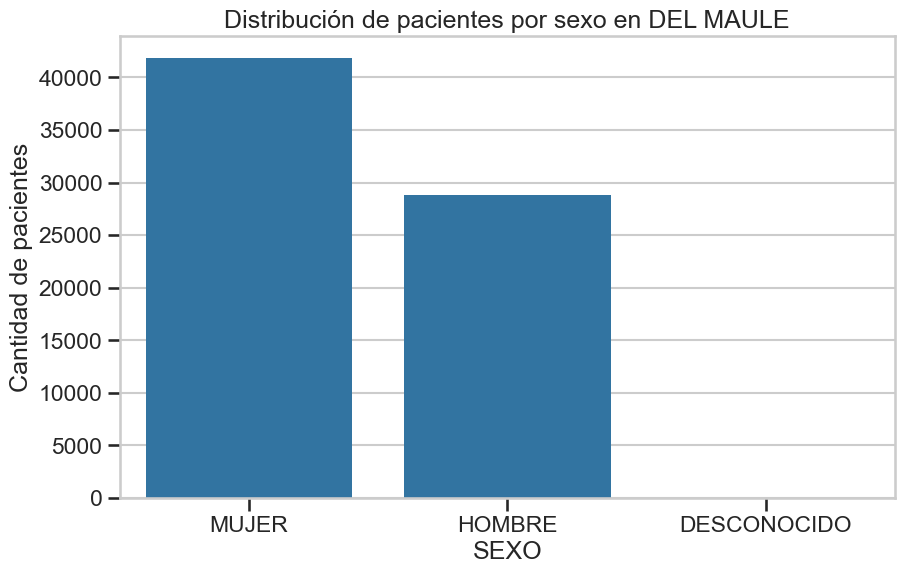

In [53]:
# Distribución por sexo
plt.figure(figsize=(10, 6))
sns.countplot(data=df_servicio, x='SEXO')
plt.title(f'Distribución de pacientes por sexo en {servicio_seleccionado}')
plt.ylabel('Cantidad de pacientes')
plt.xticks(rotation=0)
plt.show()

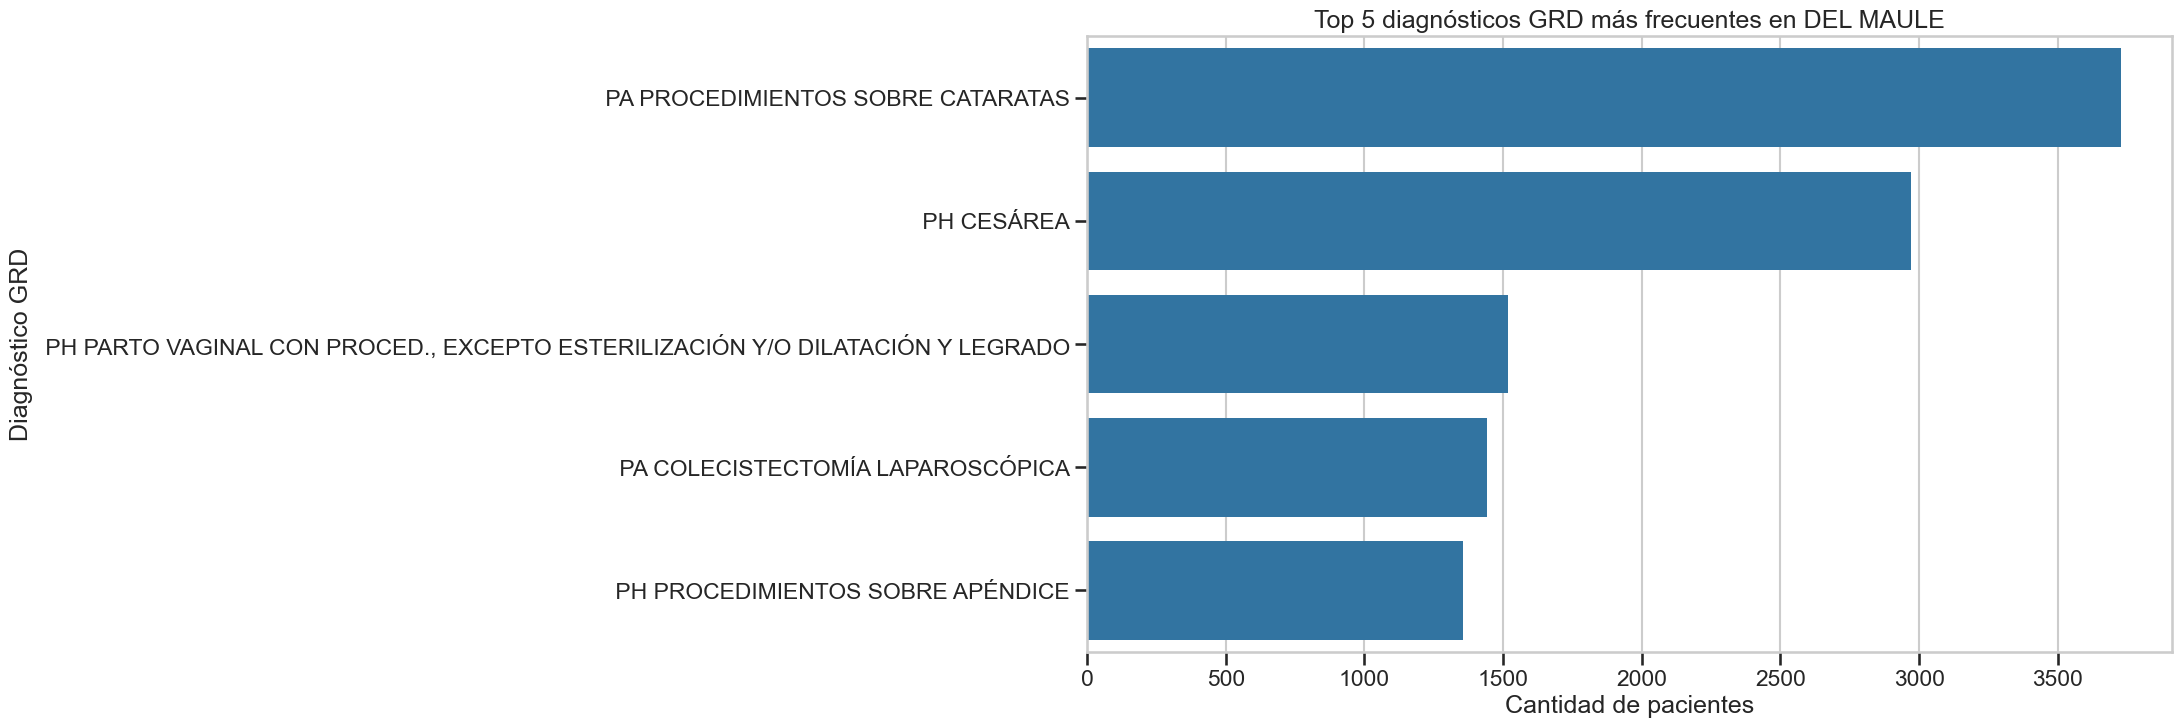

In [ ]:
# Top 5 diagnosticos más frecuentes

plt.figure(figsize=(14, 8))
top_5_grd_servicio = df_servicio['DESCRIPCION_GRD'].value_counts().head(5)
sns.barplot(x=top_5_grd_servicio.values, y=top_5_grd_servicio.index)
plt.title(f'Top 5 diagnósticos GRD más frecuentes en {servicio_seleccionado}')
plt.xlabel('Cantidad de pacientes')
plt.ylabel('Diagnóstico GRD')
plt.show()


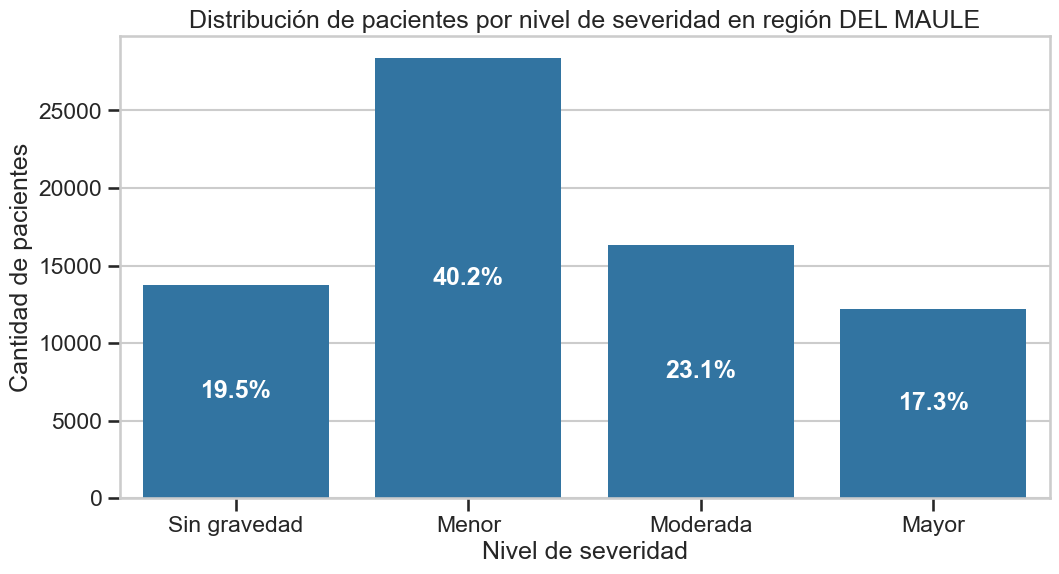

In [48]:
# Distribución por nivel de severidad
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_servicio, x='IR_29301_SEVERIDAD')
plt.title(f'Distribución de pacientes por nivel de severidad en región {servicio_seleccionado}')
plt.xlabel('Nivel de severidad')
plt.ylabel('Cantidad de pacientes')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Sin gravedad', 'Menor', 'Moderada', 'Mayor'])

# Añadir porcentaje en las barras
total = len(df_servicio)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() / 2
    ax.annotate(percentage, (x, y), ha='center', va='center', color='white', weight='bold')

plt.show()

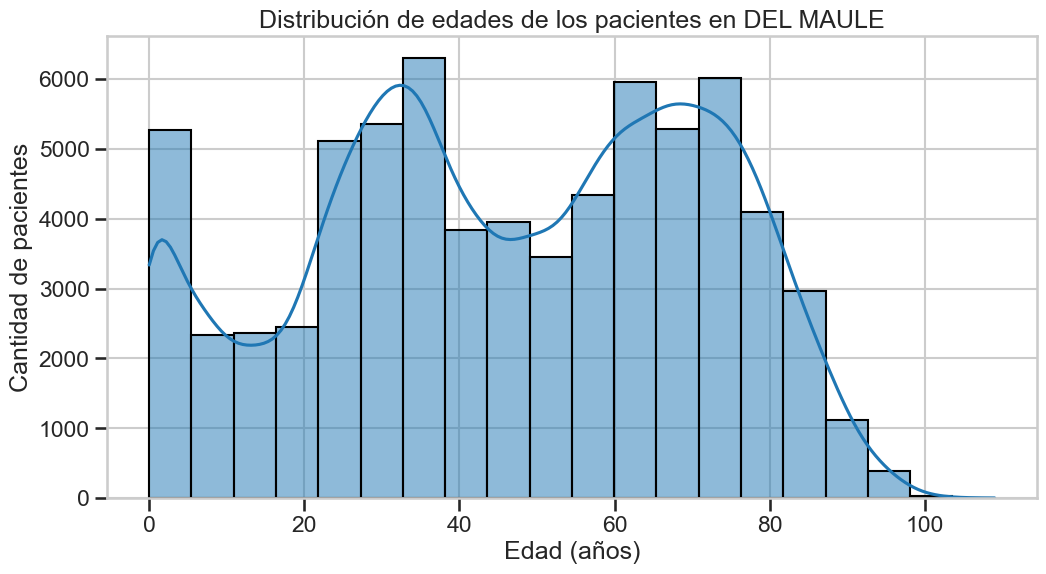

In [55]:
# Histograma de la distribución de edades
plt.figure(figsize=(12, 6))
sns.histplot(data=df_servicio, x='EDAD', bins=20, kde=True)
plt.title(f'Distribución de edades de los pacientes en {servicio_seleccionado}')
plt.xlabel('Edad (años)')
plt.ylabel('Cantidad de pacientes')
plt.show()

## c) Preguntas de Investigación

##### 1.- ¿Que tan frecuentes son los diagnosticos relacionados al parto en la región del Maule? 
##### 2.- ¿A que se debe que en esta región la mayor cantidad de pacientes se encuentran entre 30 y 40 años? 
##### 3.- ¿Que diagnosticos son los más comúnes en la categoría de severidad menor y como podemos reducir esta cifra?

## d) Desafíos

##### Pregunta 1:

Para obtener el total de diagnosticos relacionados al parto, sería ideal disponer de una tabla o lista maestra con todos los tipos de diagnosticos relacionados para así poder filtrar en el dataset de servicio de la región.

## Limitaciones

Para un análisis más profundo sería necesario disponer de datos demograficos de la zona los cuales se puedan relacionar con los resultados y visualizaciones futuras para así generar correlaciones.

Un dataset sobre la población de Chile la edad de esta sería idóneo

## e) Enfoque Preliminar

### Pregunta 2

Para responder esta pregunta, se hará primero un filtrado del dataset para solo estudiar los casos registrados de pacientes en el rango estipulado.
Luego se generarán nuevas visualizaciones para analizar los grados de severidad de estos pacientes e igualmente los diagnosticos más frecuentes.
Si estos resultados mantienen la misma tendencia que lo observado en el análisis exploratorio se verificará la distribución por genero de este rango etario.
Asimismo si la distribución se mantiene pareja a la de la población de la región, se intentará de estudiar la distribución por edad de la población de Chile además de su ubicación. Aquí se podría evidenciar que simplemente en esta región predominan las personas pertenecientes a este rango etario.

### Discusión grupal

Al finalizar la actividad, cada grupo compartirá brevemente:
1. Las principales características de su servicio de salud
2. Una de sus preguntas de investigación más interesantes
3. Un desafío significativo que identificaron en los datos

### Nota:

Esta actividad servirá como punto de partida para su proyecto del curso. Las preguntas de investigación que formulen hoy pueden evolucionar a medida que profundicen en los datos y aprendan nuevas técnicas de análisis estadístico.

## 8. Recursos adicionales

Para profundizar en el conocimiento sobre GRD y análisis de datos en salud:

1. **Documentación del sistema GRD chileno**:
   - [Boletín Informativo FONASA sobre GRD](https://www.fonasa.cl/sites/fonasa/adjuntos/Analysis02)

2. **Documentación de las bibliotecas utilizadas**:
   - [Pandas Documentation](https://pandas.pydata.org/docs/)
   - [Matplotlib Documentation](https://matplotlib.org/stable/contents.html)
   - [Seaborn Documentation](https://seaborn.pydata.org/tutorial.html)

3. **Libros recomendados**:
   - "Python for Data Analysis" por Wes McKinney
   - "Practical Statistics for Data Scientists" por Peter Bruce y Andrew Bruce
   - "Health Care Data Analytics" por Chandan K. Reddy y Charu C. Aggarwal
